# Libraries/Packages

In [1]:
# NOTE: Below are the steps to properly install the following libraries/packages in the Terminal:
# 1. Create a conda environment with Python, R, and RobustGASP (conda create --name your_env_name python r-base conda-forge::r-robustgasp)
# 2. Activate the environment (conda activate your_env_name)
# 3. Install Seaborn (pip install seaborn) 
# 4. Install UTM (pip install utm)
# 5. Install Scikit-learn (pip install scikit-learn)

# Import the necessary libraries/packages
# Requires: numpy, pandas, matplotlib, utm  (psimpy / RobustGASP no longer needed)
import time
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from filter_features import (latlon_to_xy, circdiff180,
                             build_uniform_cluster_matrix, calcfilter_feat_vectorized)

# Load and Prepare Dataset

Dataset used originates from the `Roux_selected` parquet file.

We need to have the standard deviation of the wind direction, the standard deviation of the wind speed, and the standard deviation of the power as variables.


Load "windesco_2024_tsdata_wd_corrected.parquet"

In [2]:
# NOTE: If you haven't already, "pip install pyarrow" in the Terminal to read in a .parquet file

# Read in the Data with the corrected wind direction
CorrWindDir = pd.read_parquet("../../Datasets/windesco_2024_tsdata_wd_corrected.parquet") # Protected dataset
#CorrWindDir.head()

# View each unique turbine
print(CorrWindDir.index.get_level_values("turbine_id").unique()) # Protected dataset

# Load turbine metadata
# Load the turbine metadata to plot turbine location 
turbines = pd.read_csv("../../Datasets/milford_clipper_turbine_metadata.csv")
turbines = turbines.set_index("turbine_id")
# Add the x/y coordinates of the turbines in rotor diameters
x, y = latlon_to_xy(turbines.latitude_deg.values, turbines.longitude_deg.values)
turbines["easting_m"] = x
turbines["northing_m"] = y
turbines["x_D"] = (turbines["easting_m"] -  turbines["easting_m"].min())/turbines.rotor_diameter_m.mean()
turbines["y_D"] = (turbines["northing_m"] -  turbines["northing_m"].min())/turbines.rotor_diameter_m.mean()

Index([401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414,
       415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428,
       429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442,
       443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456,
       457, 458],
      dtype='int64', name='turbine_id')


## Create a map of the chosen target turbines

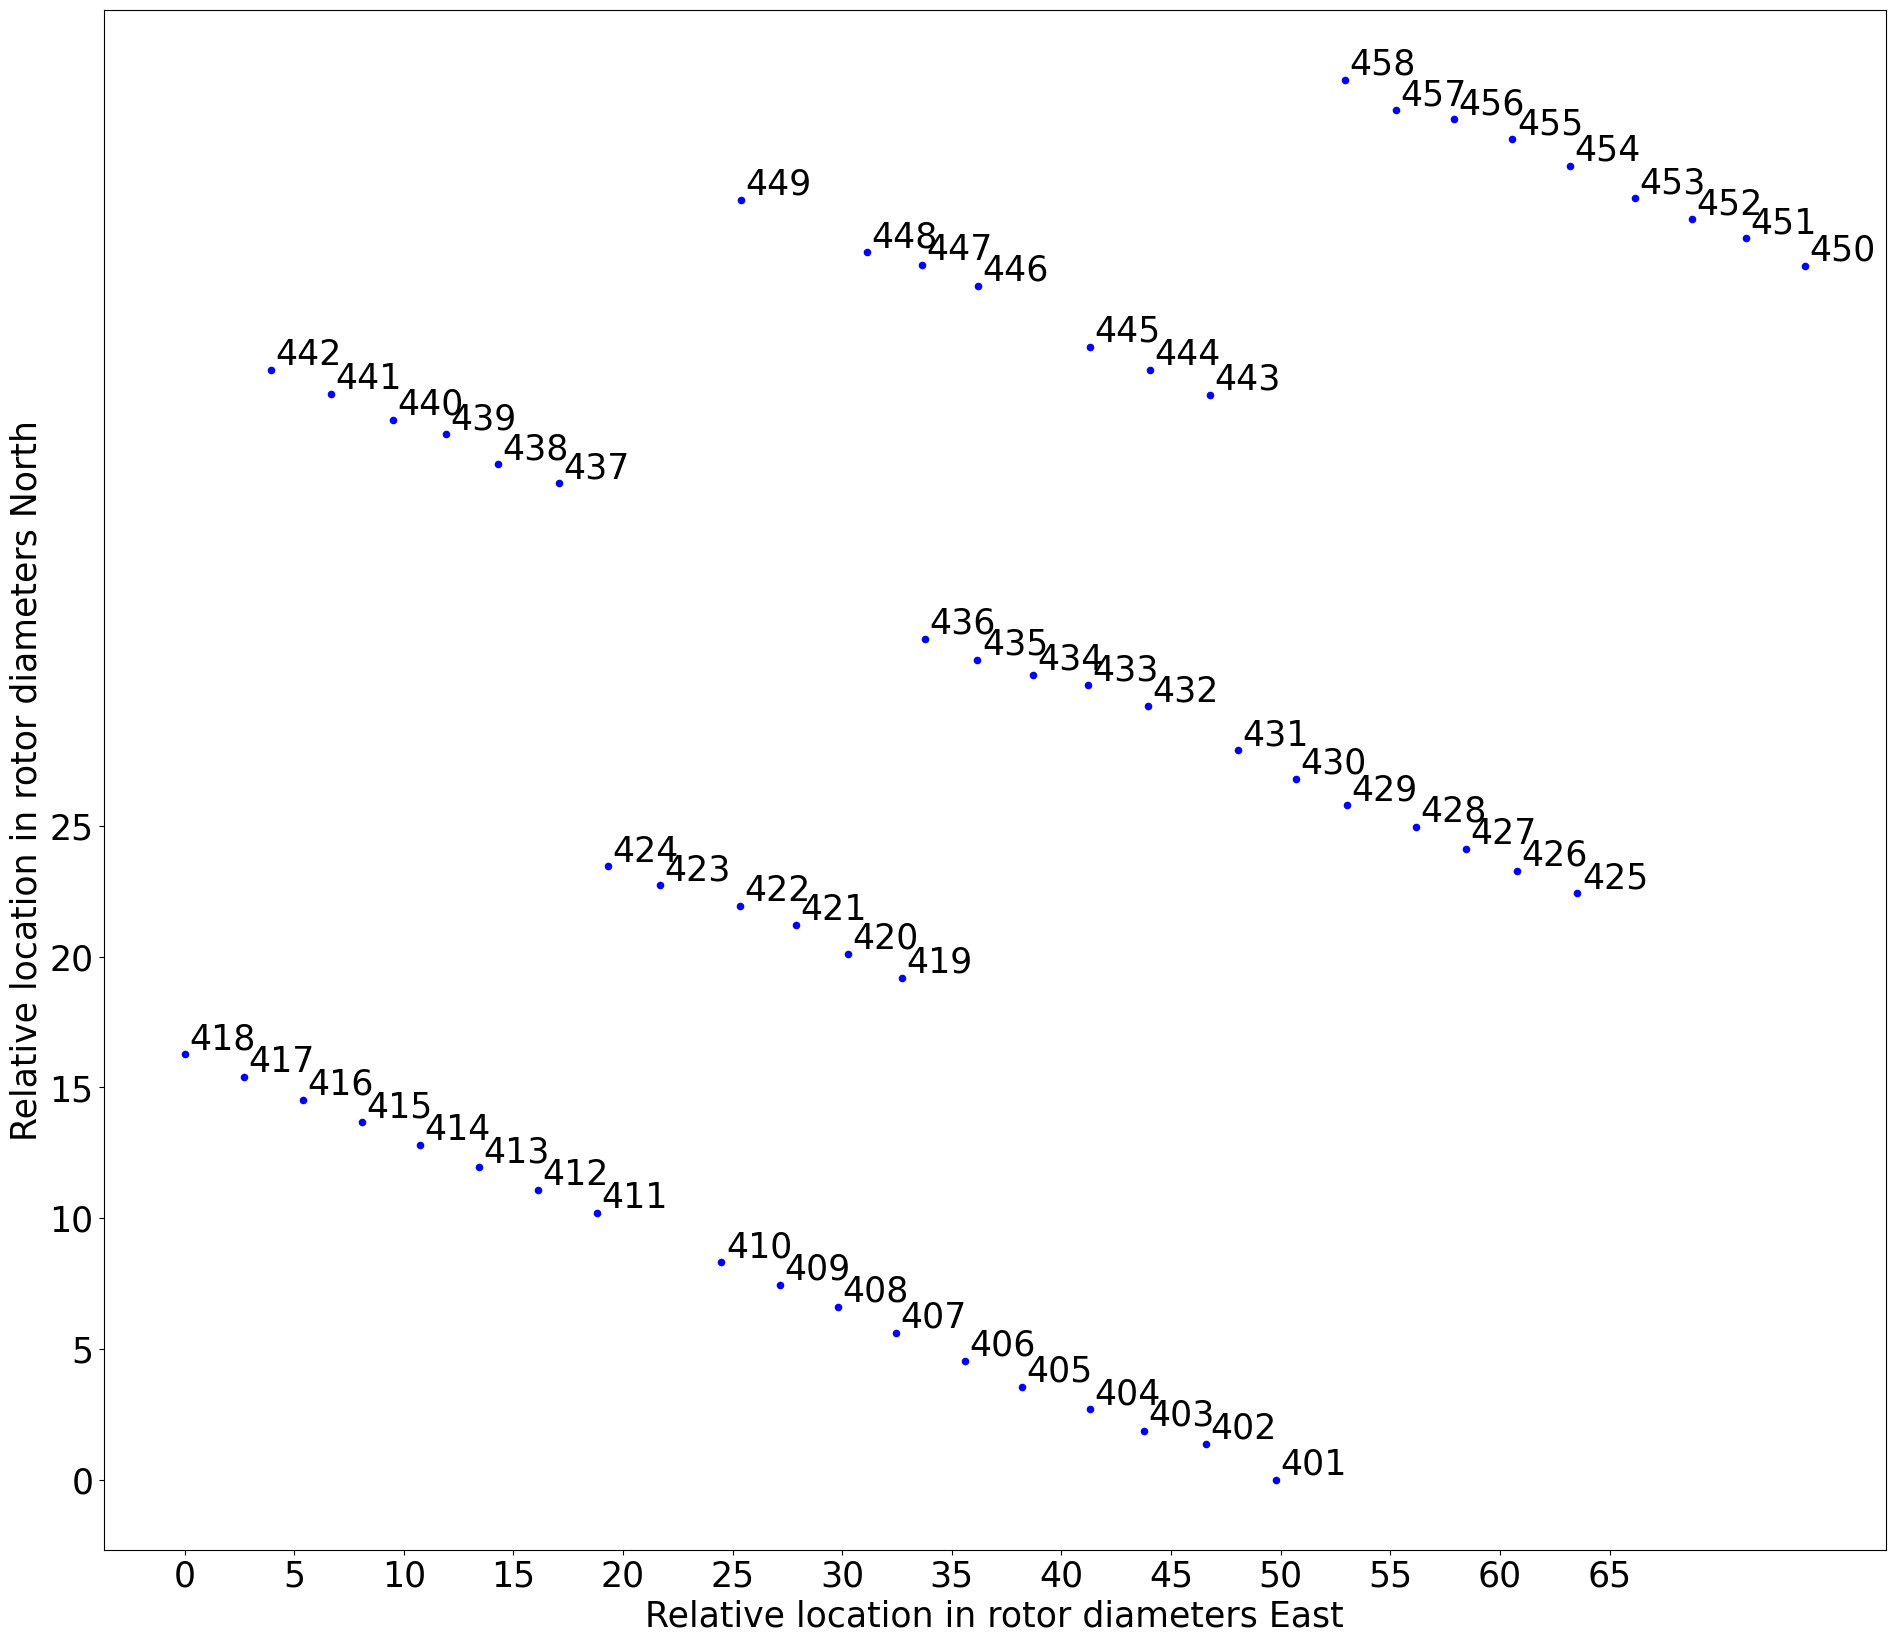

In [3]:
plt.rcParams.update({"font.size": 25})

fig = plt.figure(figsize=(23, 20))
ax = fig.add_subplot(111)

turbine_subset = turbines.loc[CorrWindDir.index.get_level_values("turbine_id").unique()]

# Create a scatterplot of the chosen target turbines
turbine_subset.plot.scatter(
    x="x_D", y="y_D", ax=ax, color="b",
    xlabel="Relative location in rotor diameters East", 
    ylabel="Relative location in rotor diameters North",
)

# Add turbine ID labels to the turbines
for i in turbine_subset.index:
    ax.text(turbine_subset.x_D[i]+0.2, turbine_subset.y_D[i]+0.2, i)

# Adjust the scales of the axes
plt.xticks(range(0, 70, 5))
plt.yticks(range(0, 30, 5))

# Save the plot as a .png file with high resolution
plt.savefig("Figure_1.png", dpi=300, bbox_inches="tight")


# Display the map
plt.show()

## Calculate TI per turbine on a 10-minute basis using SCADA data wind speed

In [4]:
# Calculate Ti per turbine on 10 minute basis using SCADA data windspeed 
# and forward fill because Ti is typically computed on a 10 minute basis
# To calculate the standard deviation on 10 minutes we compute the square root of the mean of the squared 1 minute standard deviations
df = CorrWindDir[["windspeed_mps_sd", "windspeed_mps_mn", "global_ti"]].copy()
df["windspeed_mps_sd2"] = df["windspeed_mps_sd"]**2
df["ti_1m"] = df["windspeed_mps_sd"] / df["windspeed_mps_mn"]

df_resample = pd.DataFrame()

# Perform the calculations 1 turbine at a time
for tid in df.index.get_level_values("turbine_id").unique():
    dft = df.loc[tid].copy()
    dft["turbine_id"] = tid
    
    dfr = dft.rolling("10min", closed = "right").mean()
    dfr["windspeed_mps_sd"] = np.sqrt(dfr["windspeed_mps_sd2"])
    dfr["ti"] = dfr["windspeed_mps_sd"] / dfr["windspeed_mps_mn"]
    
    dft["ti"] = dfr["ti"]
    dft["ti"] = dft["ti"].ffill(limit=10).bfill(limit=10) # This isn't perfect since it is based on number of data points and not time
    dft = dft.reset_index().set_index(["turbine_id", "ts"])
    
    df_resample = pd.concat([df_resample, dft])

## Select the variables you want/need from the raw data

In [5]:
# NOTE: Can include more variables here surrounding wind speed and/or power

# Create a new dataframe with all of the variables that we want and need
LukeSelectedAll = CorrWindDir[[
    "toggle_state_high",
    "offline",
    "is_derated",
    "state",
]].copy()

# Add turbulence intensity
LukeSelectedAll["ti"] = df_resample["ti"]

# Add air density
#LukeSelectedAll["airdensity_kgpm3"] = CorrWindDir["airdensity_kgpm3_mn"]

# Add wind speed
LukeSelectedAll["windspeed_mps"] = CorrWindDir["windspeed_mps_mn"]

# Add nacelle direction
LukeSelectedAll["nacelledir_deg"] = CorrWindDir["nacdirestimate_deg_mn"].fillna(CorrWindDir["nacelledirection_deg_mn_corr"])

# Add wind direction
LukeSelectedAll["winddir_deg"] = CorrWindDir["winddirestimate_deg_mn"].fillna(CorrWindDir["winddirection_deg_mn_corr"])

# Calculate yaw error from WeAdapt data if available, otherwise use SCADA data and assume WeAdapt is not present
LukeSelectedAll["windvane_deg"] = circdiff180(CorrWindDir["winddirestimate_deg_mn"], CorrWindDir["nacdirestimate_deg_mn"])

# Replace NaNs with SCADA when WeAdapt data is not available
LukeSelectedAll["windvane_deg"] = LukeSelectedAll["windvane_deg"].fillna(CorrWindDir["yawerror_deg_mn"])

# Add power
LukeSelectedAll["power_kw"] = CorrWindDir["realpower_kw_mn"]

# Set nacelle position set point to nan for turbines that aren't currently being controlled to other values
#LukeSelectedAll["nacpossetpoint_deg"] = CorrWindDir["nacpossetpoint_deg"].where((CorrWindDir.state == "active-remote-on"), np.nan)

# Set target offset to 0 for turbines that aren't currently being controlled to other values
LukeSelectedAll["target_windvane_deg"] = CorrWindDir["opt_yaw"].where((CorrWindDir.state == "active-remote-on"), 0)

# Add the standard deviation of the wind direction
#LukeSelectedAll["winddirection_deg_sd"] = CorrWindDir["winddirection_deg_sd"]

# Add the standard deviation of the wind speed
LukeSelectedAll["windspeed_mps_sd"] = CorrWindDir["windspeed_mps_sd"]

# Add the standard deviation of the power
#LukeSelectedAll["power_kw_sd"] = CorrWindDir["realpower_kw_sd"]

# Add the rotor speed
#LukeSelectedAll["rotorspeed_rpm_mn"] = CorrWindDir["rotorspeed_rpm_mn"]

# Add the yaw error standard deviation
#LukeSelectedAll["yawerror_deg_sd"] = CorrWindDir["yawerror_deg_sd"]

In [6]:
idx_main = LukeSelectedAll.index
idx_ti = df_resample.index

print("main rows:", len(idx_main))
print("ti rows:", len(idx_ti))
print("ti duplicated:", idx_ti.duplicated().sum())
print("in main but not in ti:", len(idx_main.difference(idx_ti)))
print("in ti but not in main:", len(idx_ti.difference(idx_main)))

main rows: 10427182
ti rows: 10427182
ti duplicated: 0
in main but not in ti: 0
in ti but not in main: 0


In [7]:
# NaNs that exist because the (turbine, ts) pair is entirely absent from df_resample
missing_pairs = LukeSelectedAll.index.difference(df_resample.index)
print("alignment-miss rows:", len(missing_pairs))

# NaNs that are real (pair exists in df_resample but value is NaN there)
real_nans = df_resample["ti"].isna().groupby(level="turbine_id").sum()
print(real_nans)

alignment-miss rows: 0
turbine_id
401    66151
402    68981
403    66152
404    66151
405    66152
406    66152
407    66150
408    66151
409    66150
410    72748
411    67329
412    70169
413    67571
414    66161
415    66160
416    66225
417    66161
418    67592
419    67253
420    67491
421    66159
422    66159
423    66158
424    67572
425    66176
426    67562
427    66160
428    66151
429    66150
430    66151
431    66152
432    66150
433    66891
434    66535
435    66161
436    66161
437    66337
438    66674
439    66337
440    68084
441    67748
442    66677
443    67321
444    69945
445    66601
446    66151
447    66162
448    66160
449    66993
450    66151
451    66149
452    66150
453    67321
454    68639
455    69903
456    66150
457    66289
458    66168
Name: ti, dtype: int64


In [8]:
for col in ["windspeed_mps_sd", "windspeed_mps_mn", "windspeed_mps_sd2", "ti_1m", "ti"]:
    n = df_resample[col].isna().groupby(level="turbine_id").sum().mean()
    print(f"{col:20s} mean NaN/turbine: {n:.0f}")

windspeed_mps_sd     mean NaN/turbine: 68030
windspeed_mps_mn     mean NaN/turbine: 7570
windspeed_mps_sd2    mean NaN/turbine: 68030
ti_1m                mean NaN/turbine: 71305
ti                   mean NaN/turbine: 66890


In [9]:
# rebuild one turbine and inspect the pre-fill NaN count
tid = df.index.get_level_values("turbine_id").unique()[0]
dft = df.loc[tid].copy()
dfr = dft.rolling("10min", closed="right").mean()
dfr["windspeed_mps_sd"] = np.sqrt(dfr["windspeed_mps_sd2"])
dfr["ti"] = dfr["windspeed_mps_sd"] / dfr["windspeed_mps_mn"]

print("pre-fill ti NaN:", dfr["ti"].isna().sum())
print("post-fill would be:", dfr["ti"].ffill(limit=10).bfill(limit=10).isna().sum())

pre-fill ti NaN: 67071
post-fill would be: 66151


In [10]:
CorrWindDir["windspeed_mps_sd"].isna().groupby(level="turbine_id").sum()
#CorrWindDir["windspeed_mps_mn"].isna().groupby(level="turbine_id").sum()

turbine_id
401    67021
402    69808
403    66955
404    67060
405    66994
406    66973
407    67087
408    67001
409    66987
410    73661
411    68473
412    71343
413    68497
414    67206
415    67176
416    67271
417    67062
418    68519
419    68187
420    68394
421    67220
422    67205
423    67086
424    68568
425    67300
426    68542
427    67358
428    67263
429    67164
430    67134
431    67152
432    67163
433    67906
434    67546
435    67174
436    67178
437    68160
438    68542
439    67991
440    69867
441    69603
442    68418
443    68635
444    70965
445    67772
446    67195
447    67205
448    67199
449    68092
450    67343
451    67363
452    67206
453    68798
454    69840
455    71460
456    67215
457    69013
458    67249
Name: windspeed_mps_sd, dtype: int64

In [11]:
print(LukeSelectedAll.index.get_level_values("ts").dtype)
print(df_resample.index.get_level_values("ts").dtype)

datetime64[ns]
datetime64[ns]


In [12]:
print(LukeSelectedAll.columns)
print(LukeSelectedAll.index)

Index(['toggle_state_high', 'offline', 'is_derated', 'state', 'ti',
       'windspeed_mps', 'nacelledir_deg', 'winddir_deg', 'windvane_deg',
       'power_kw', 'target_windvane_deg', 'windspeed_mps_sd'],
      dtype='object')
MultiIndex([(401, '2024-01-01 00:01:00'),
            (401, '2024-01-01 00:02:00'),
            (401, '2024-01-01 00:03:00'),
            (401, '2024-01-01 00:04:00'),
            (401, '2024-01-01 00:05:00'),
            (401, '2024-01-01 00:06:00'),
            (401, '2024-01-01 00:07:00'),
            (401, '2024-01-01 00:08:00'),
            (401, '2024-01-01 00:09:00'),
            (401, '2024-01-01 00:10:00'),
            ...
            (458, '2024-05-12 23:51:00'),
            (458, '2024-05-12 23:52:00'),
            (458, '2024-05-12 23:53:00'),
            (458, '2024-05-12 23:54:00'),
            (458, '2024-05-12 23:55:00'),
            (458, '2024-05-12 23:56:00'),
            (458, '2024-05-12 23:57:00'),
            (458, '2024-05-12 23:58:00'),
  

In [13]:
print(LukeSelectedAll["ti"].isna().groupby(level="turbine_id").sum())

turbine_id
401    66151
402    68981
403    66152
404    66151
405    66152
406    66152
407    66150
408    66151
409    66150
410    72748
411    67329
412    70169
413    67571
414    66161
415    66160
416    66225
417    66161
418    67592
419    67253
420    67491
421    66159
422    66159
423    66158
424    67572
425    66176
426    67562
427    66160
428    66151
429    66150
430    66151
431    66152
432    66150
433    66891
434    66535
435    66161
436    66161
437    66337
438    66674
439    66337
440    68084
441    67748
442    66677
443    67321
444    69945
445    66601
446    66151
447    66162
448    66160
449    66993
450    66151
451    66149
452    66150
453    67321
454    68639
455    69903
456    66150
457    66289
458    66168
Name: ti, dtype: int64


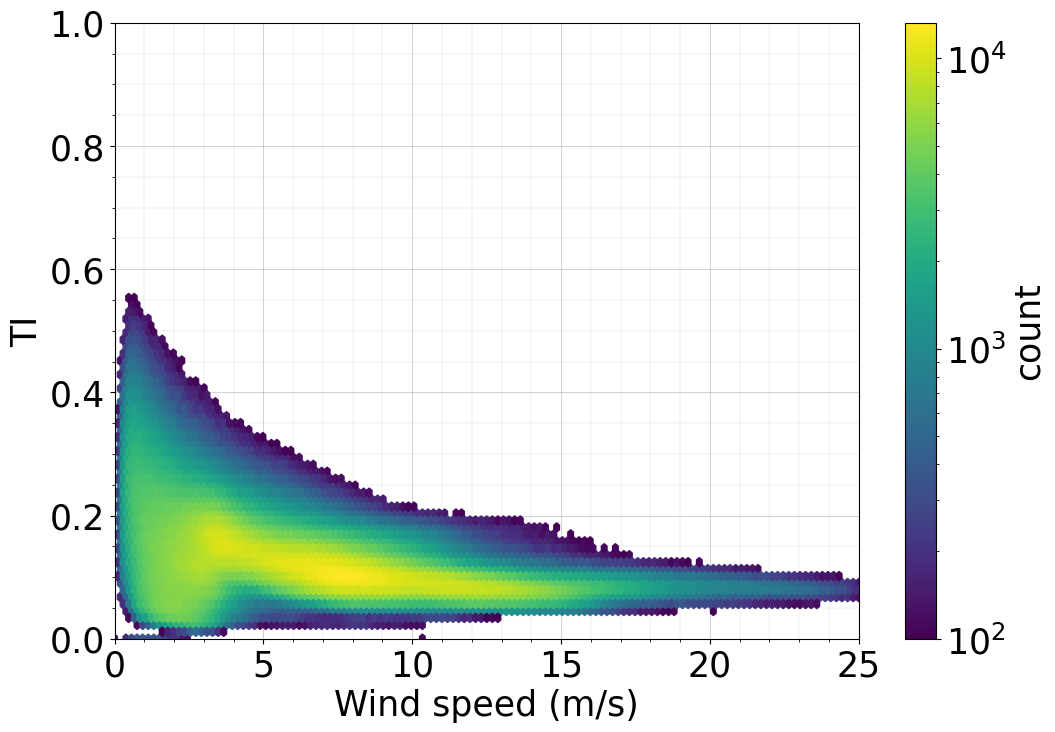

In [14]:
fig, ax = plt.subplots(figsize=(12,8))
hb = ax.hexbin(LukeSelectedAll["windspeed_mps"], LukeSelectedAll["ti"], gridsize=(500,1500), mincnt=100, bins='log')
fig.colorbar(hb, label='count')
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel('TI')
ax.set_axisbelow(True)
ax.set_xlim(0,25)
ax.set_ylim(0,1)
ax.grid(True, color='gray', linewidth=1.5, alpha=0.4)
ax.minorticks_on()
ax.grid(which='major', color='gray', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', color='gray', linewidth=0.3, alpha=0.3)
plt.show()

## Load "Roux_selected" data

In [15]:
# Load in the old Rouxselected_all and compare to the LukeSelectedAll
RouxData = pd.read_parquet("../../Datasets/milford2024_data_Rouxselected_all.parquet") # Protected dataset, is not shared
RouxData.head()

toggle_state_high  offline  is_waked  \
turbine_id ts                                                          
401        2024-01-01 00:01:00              False     True     False   
           2024-01-01 00:02:00              False     True     False   
           2024-01-01 00:03:00              False     True     False   
           2024-01-01 00:04:00              False     True     False   
           2024-01-01 00:05:00              False     True     False   

                                is_derated   state  ti  airdensity_kgpm3  \
turbine_id ts                                                              
401        2024-01-01 00:01:00       False  bypass NaN               NaN   
           2024-01-01 00:02:00       False  bypass NaN               NaN   
           2024-01-01 00:03:00       False  bypass NaN               NaN   
           2024-01-01 00:04:00       False  bypass NaN               NaN   
           2024-01-01 00:05:00       False  bypass NaN               NaN   

                                windspeed_mps  nacelledir_deg  winddir_deg  \
turbine_id ts                                                                
401        2024-01-01 00:01:00       1.307963      179.662916   293.513958   
           2024-01-01 00:02:00       1.358814      179.661774   291.373139   
           2024-01-01 00:03:00       1.349636      179.661774   288.380929   
           2024-01-01 00:04:00       1.365882      179.661774   287.584789   
           2024-01-01 00:05:00       1.450377      179.661774   287.237085   

                                windvane_deg  power_kw  nacpossetpoint_deg  \
turbine_id ts                                                                
401        2024-01-01 00:01:00    113.851042       0.0                 NaN   
           2024-01-01 00:02:00    111.711365       0.0                 NaN   
           2024-01-01 00:03:00    108.719155       0.0                 NaN   
           2024-01-01 00:04:00    107.923015       0.0                 NaN   
           2024-01-01 00:05:00    107.575311       0.0                 NaN   

                                target_windvane_deg  
turbine_id ts                                        
401        2024-01-01 00:01:00                  0.0  
           2024-01-01 00:02:00                  0.0  
           2024-01-01 00:03:00                  0.0  
           2024-01-01 00:04:00                  0.0  
           2024-01-01 00:05:00                  0.0

In [16]:
# Look at the columns from RouxData
for i in range(len(RouxData.columns)):
    print("Column #"+str(i)+" "+str(RouxData.columns[i]))

Column #0 toggle_state_high
Column #1 offline
Column #2 is_waked
Column #3 is_derated
Column #4 state
Column #5 ti
Column #6 airdensity_kgpm3
Column #7 windspeed_mps
Column #8 nacelledir_deg
Column #9 winddir_deg
Column #10 windvane_deg
Column #11 power_kw
Column #12 nacpossetpoint_deg
Column #13 target_windvane_deg


## Compare the visualizations of wind direction, wind speed, and power between the Roux_selected data and the data with the selected variables

Confirm that "LukeSelectedAll" contains the same data as the original handling of the wind turbine dataset.

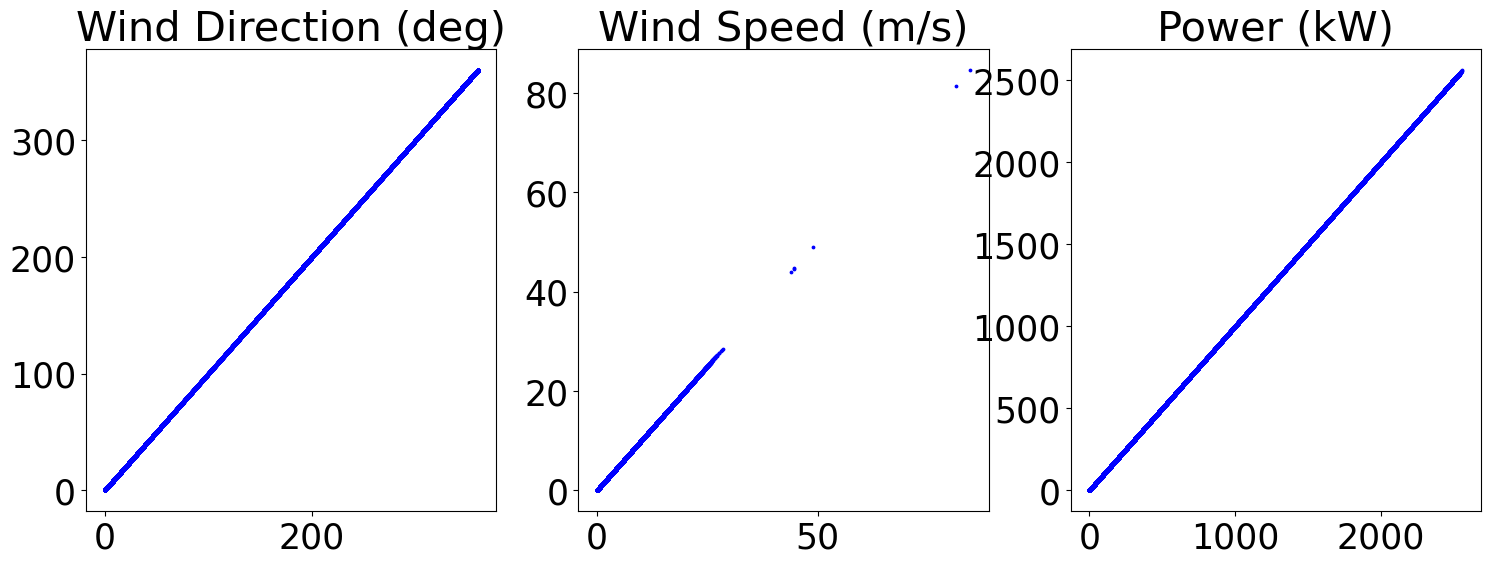

In [17]:
# Check the wind direction, wind speed, and power

# Create a figure with 1 row and 3 columns for 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Generate the first plot for wind direction
x1 = RouxData.loc[401].winddir_deg
y1 = LukeSelectedAll.loc[401].winddir_deg
ax[0].scatter(x1, y1, 3, "b")
ax[0].set_title("Wind Direction (deg)")

# Generate the second plot for wind speed
x2 = RouxData.loc[401].windspeed_mps
y2 = LukeSelectedAll.loc[401].windspeed_mps
ax[1].scatter(x2, y2, 3, "b")
ax[1].set_title("Wind Speed (m/s)")

# Generate the third plot for power
x3 = RouxData.loc[401].power_kw
y3 = LukeSelectedAll.loc[401].power_kw
ax[2].scatter(x3, y3, 3, "b")
ax[2].set_title("Power (kW)")

# Display the plot
plt.show()

In [18]:
# Save the dataframe with selected variables as a .parquet file
#LukeSelectedAll.to_parquet("milford2024_data_LukeSelected_all.parquet") ## Protected dataset, is not shared

# Generate DataFrame with Filtering Variables

The dataframe will contain:

- Reference Data (the mean wind direction measurement of the nearest x turbines, the mean wind speed measurement of the nearest x turbines, the mean power measurement of the nearest x turbines)
- Wind Direction Circular Difference between cluster and target turbine (rolling)
- Wind Direction Ratio of Complex Standard Deviation between cluster and target turbine (rolling)
- Wind Direction Circular Difference between cluster and target turbine standard deviation
- Standard Deviation from Farm Average Wind Direction
- Target Turbine:
    - Wind Direction
    - Wind Speed
    - Wind Vane
    - Power
    - Nacelle Direction
    - Target Wind Vane
 
Here we have updated `calcfilter_feat_vectorized` in order to generate the anomaly statistics (wind direction circular difference, wind diration ratio of complex standard deviation, wind direction standard deviation, and z-score from time-stamp average wind direction).

## Load LukeSelectedAll

Once created, the previous section can be skipped and the dataset loaded directly from this step. 

In [19]:
# Load the sensor data
LukeSelectedAll = pd.read_parquet("../../Datasets/milford2024_data_LukeSelected_all.parquet")

for i in range(len(LukeSelectedAll.columns)):
    print("Column #"+str(i)+" "+str(LukeSelectedAll.columns[i]))

Column #0 toggle_state_high
Column #1 offline
Column #2 is_derated
Column #3 state
Column #4 ti
Column #5 windspeed_mps
Column #6 nacelledir_deg
Column #7 winddir_deg
Column #8 windvane_deg
Column #9 power_kw
Column #10 target_windvane_deg
Column #11 windspeed_mps_sd


In [20]:
# Attain the summary statistics for wind direction, wind speed, and power

cols = [
    "winddir_deg",
    "windspeed_mps",
    "power_kw"
]

summary = LukeSelectedAll[cols].describe().T
summary["nan_%"] = LukeSelectedAll[cols].isna().mean() * 100

print(summary)

                    count        mean         std       min         25%  \
winddir_deg    10046679.0  180.591722  100.412230  0.000027  140.752787   
windspeed_mps   9988124.0    6.490381    4.560218  0.000000    2.834237   
power_kw       10023796.0  553.147161  789.165818  0.000000    0.000000   

                      50%         75%          max     nan_%  
winddir_deg    185.789435  219.025672   359.999992  3.649145  
windspeed_mps    5.678491    9.148333    98.710961  4.210706  
power_kw       103.298246  870.220556  7264.171429  3.868600  


## Make a Filtered Dataset
# Run all of the data through the filter creator (vectorized)

Using the new vectorized function expect about 3 minutes to solve. 

In [21]:
# NOTE: Can fiddle with the parameter(s) here
# Choose a time slice
t10 = "2024-01-01"
t20 = "2024-05-13"

# Choose a Cluster Number for calculating reference wind direction, wind speed, and power
clusternum = 25

# Choose a Rolling window for circular mean difference and ratio of complex standard deviation features
n1 = 10

# Choose a Rolling window for the standard deviation of circular difference
n2 = 10

# Format the date
t1 = t10+" 00:00:00"
t2 = t20+" 00:00:00"

# Select a window to look at.
LukeSelectedSome = LukeSelectedAll.sort_index().loc(axis=0)[:, t1:t2]

# Decide how many days we have
d1 = pd.to_datetime(t1)
d2 = pd.to_datetime(t2)
dif = d2-d1
total_days = dif.days

# Set the number of hours in each chunk
hpc = 12

# Calculate the number of equally sized time blocks
n_parts = int((total_days)*(24/hpc)+1)

# Identify the number of blocks needed to achieve that
time_chunks = pd.date_range(start=t1, end=t2, periods=n_parts)

# Reindex the entire dataframe to have no missing timestamps by replacing the missing values with nans 
new_t_index = pd.date_range(start=t1, end=t2, freq="min")
turbsints = [int(i) for i in range(401, 459)]
new_ind = pd.MultiIndex.from_product([turbsints, new_t_index], names=["turbine_id", "ts"])
LukeSelectedSome = LukeSelectedSome.reindex(new_ind)
print(time_chunks)

# Calculate the turbine distance weighting matrix
cluster_matrix, turblist = build_uniform_cluster_matrix(
    turbines, turbines, clusternum
)
start = time.time()

full_output = calcfilter_feat_vectorized(
    turbines,
    LukeSelectedSome,
    cluster_matrix,
    n1,
    n2,
)

print("Runtime:", time.time() - start)
print("Full run time:", time.time() - start)

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 12:00:00',
               '2024-01-02 00:00:00', '2024-01-02 12:00:00',
               '2024-01-03 00:00:00', '2024-01-03 12:00:00',
               '2024-01-04 00:00:00', '2024-01-04 12:00:00',
               '2024-01-05 00:00:00', '2024-01-05 12:00:00',
               ...
               '2024-05-08 12:00:00', '2024-05-09 00:00:00',
               '2024-05-09 12:00:00', '2024-05-10 00:00:00',
               '2024-05-10 12:00:00', '2024-05-11 00:00:00',
               '2024-05-11 12:00:00', '2024-05-12 00:00:00',
               '2024-05-12 12:00:00', '2024-05-13 00:00:00'],
              dtype='datetime64[us]', length=267, freq=None)


c:\Users\aidan\Documents\AidanOther\RouxStudiesEdits\Updated_Scripts\clean_version_updated\filter_features.py:183: RuntimeWarning: divide by zero encountered in divide
  std_ratio = target_std_roll / ref_std_roll  # will produce inf where ref_std_roll==0, same as legacy
c:\Users\aidan\Documents\AidanOther\RouxStudiesEdits\Updated_Scripts\clean_version_updated\filter_features.py:183: RuntimeWarning: invalid value encountered in divide
  std_ratio = target_std_roll / ref_std_roll  # will produce inf where ref_std_roll==0, same as legacy
c:\Users\aidan\Documents\AidanOther\RouxStudiesEdits\Updated_Scripts\clean_version_updated\filter_features.py:208: RuntimeWarning: Mean of empty slice
  mx = np.nanmean(x, axis=1)
c:\Users\aidan\Documents\AidanOther\RouxStudiesEdits\Updated_Scripts\clean_version_updated\filter_features.py:209: RuntimeWarning: Mean of empty slice
  my = np.nanmean(y, axis=1)


Runtime: 227.924663066864
Full run time: 227.93596577644348


In [ ]:
# Save the resulting dataframe as a .parquet file
# full_output.to_parquet("working_datasets/datawithFF_roll10mins.parquet")